In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import math
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

I0000 00:00:1778449781.723358    1235 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778449782.096716    1235 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778449783.672890    1235 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


CARGA Y EXPLORACIÓN

In [2]:
data, metadatos = tfds.load('fashion_mnist', as_supervised=True, with_info=True)
metadatos

I0000 00:00:1778449786.482581    1235 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9507 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


tfds.core.DatasetInfo(
    name='fashion_mnist',
    full_name='fashion_mnist/3.0.1',
    description="""
    Fashion-MNIST is a dataset of Zalando's article images consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes.
    """,
    homepage='https://github.com/zalandoresearch/fashion-mnist',
    data_dir='/home/revid/tensorflow_datasets/fashion_mnist/3.0.1',
    file_format=tfrecord,
    download_size=29.45 MiB,
    dataset_size=36.42 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{DBLP:journal

In [3]:
nombre_clases = metadatos.features['label'].names
num_ej_entrenamiento = metadatos.splits['train'].num_examples
num_ej_prueba = metadatos.splits['test'].num_examples
print(f"Clases: {nombre_clases}")
print(f"Ejemplos de entrenamiento: {num_ej_entrenamiento}")
print(f"Ejemplos de prueba: {num_ej_prueba}")

Clases: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Ejemplos de entrenamiento: 60000
Ejemplos de prueba: 10000


I0000 00:00:1778449787.089762    1822 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
W0000 00:00:1778449787.118926    1828 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


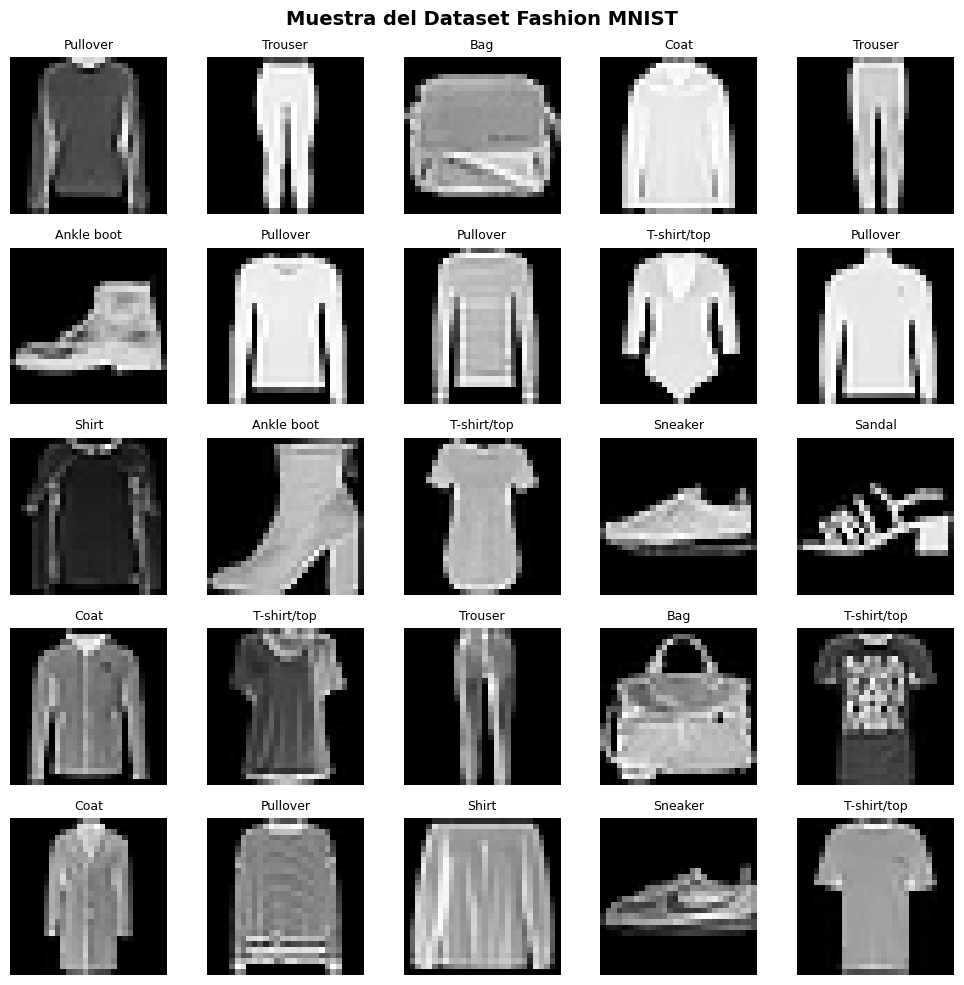

In [4]:
# Visualización de 25 ejemplos del dataset
datos_raw = data['train']

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, (imagen, etiqueta) in enumerate(datos_raw.take(25)):
    ax = axes[i // 5, i % 5]
    ax.imshow(imagen.numpy().squeeze(), cmap='gray')
    ax.set_title(nombre_clases[etiqueta.numpy()], fontsize=9)
    ax.axis('off')
plt.suptitle("Muestra del Dataset Fashion MNIST", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Estamos ante un dataset de 70 mil imagenes y 10 posibles categorías. Son prendas de ropa de Zalando (dataset proporcionado por ellos), las imagenes son de 28*28 pixeles y usan una escala de grises. Usaré tensorflow para crear un modelo que sea capaz de reconocer que prenda es.

PREPROCESAMIENTO DE LOS DATOS
Voy a usar 2 herramientas para moldear los dtoas en favor del modelo. La normalización sirve para pasar los datos de color de 0-255 a 0-1. La augmentación se usa para realizar ciertas variaciones en los datos de entrenamiento para dar una amplia perspectiva al modelo.

In [5]:
TAMAÑO_LOTE = 64 
AUTOTUNE = tf.data.AUTOTUNE

#Normalización
def normalizar(imagen, etiqueta):
    imagen = tf.cast(imagen, tf.float32) / 255.0
    return imagen, etiqueta

#Augmentación (solo para entrenamiento)
def aumentar(imagen, etiqueta):
    imagen = tf.image.random_flip_left_right(imagen)          # Espejo horizontal
    imagen = tf.image.random_brightness(imagen, max_delta=0.1) # Variación de brillo
    imagen = tf.image.random_contrast(imagen, 0.9, 1.1)        # Variación de contraste
    imagen = tf.clip_by_value(imagen, 0.0, 1.0)                # Asegurar rango válido
    return imagen, etiqueta

#Pipeline de entrenamiento
datos_entrenamiento = (
    data['train']
    .map(normalizar, num_parallel_calls=AUTOTUNE)
    .cache()                             # Cachear tras normalización
    .shuffle(num_ej_entrenamiento)        # Mezclar toda la época
    .map(aumentar, num_parallel_calls=AUTOTUNE)  # Augmentación DESPUÉS del shuffle
    .batch(TAMAÑO_LOTE)
    .prefetch(AUTOTUNE)                  # Preparar el siguiente lote en paralelo
)

#Pipeline de prueba (sin augmentación)
datos_prueba = (
    data['test']
    .map(normalizar, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(TAMAÑO_LOTE)
    .prefetch(AUTOTUNE)
)

Tras varias pruebas he escogido un modelo CNN que extrae características locales (bordes, texturas, patrones) antes de clasificar. Este modelo da mejores resultados que el `Flatten → Dense → Dense` que usé en un principio.

In [6]:
def crear_modelo():
    modelo = tf.keras.Sequential([
        # --- Bloque Convolucional 1 ---
        tf.keras.layers.Conv2D(32, (3, 3), padding='same', input_shape=(28, 28, 1)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.Conv2D(32, (3, 3), padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.25),

        # --- Bloque Convolucional 2 ---
        tf.keras.layers.Conv2D(64, (3, 3), padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.Conv2D(64, (3, 3), padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.25),

        # --- Clasificador ---
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return modelo

modelo = crear_modelo()
modelo.summary()

/home/revid/tensor/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,426 (3.33 MB)

 Trainable params: 871,530 (3.32 MB)

 Non-trainable params: 896 (3.50 KB)

COMPILACIÓN Y CALLBACKS
Voy a usar callbacks para detener la perdida de valores en caso de no mejorar el accuracy y ReduceLROnPlateau para que el modelo no se estanque en el aprendizaje automático.

In [7]:
# Compilación con learning rate explícito
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,      # Reduce LR a la mitad
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='mejor_modelo.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [8]:
#ENTRENAMIENTO
EPOCHS = 30  # EarlyStopping detendrá antes si no mejora

historial = modelo.fit(
    datos_entrenamiento,
    epochs=EPOCHS,
    validation_data=datos_prueba,   # MEJORA: monitorizar validación en cada época
    callbacks=callbacks
)

print(f"\nEntrenamiento finalizado en época {len(historial.history['loss'])}")

Epoch 1/30


I0000 00:00:1778449791.505295    1793 service.cc:153] XLA service 0x73a78c03d120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778449791.505326    1793 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4080 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1778449791.562517    1793 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778449791.903778    1793 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1778449791.985952    1793 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4905__.63


  5/938 ━━━━━━━━━━━━━━━━━━━━ 30s 33ms/step - accuracy: 0.1883 - loss: 3.0722 

I0000 00:00:1778449798.687858    1793 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


926/938 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7585 - loss: 0.7145

I0000 00:00:1778449802.884059    1792 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4905__.63


938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7593 - loss: 0.7120
Epoch 1: val_accuracy improved from None to 0.88320, saving model to mejor_modelo.keras

Epoch 1: finished saving model to mejor_modelo.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.8206 - loss: 0.5121 - val_accuracy: 0.8832 - val_loss: 0.3324 - learning_rate: 0.0010
Epoch 2/30
934/938 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8734 - loss: 0.3588
Epoch 2: val_accuracy did not improve from 0.88320
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8787 - loss: 0.3449 - val_accuracy: 0.8674 - val_loss: 0.3597 - learning_rate: 0.0010
Epoch 3/30
931/938 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8872 - loss: 0.3174
Epoch 3: val_accuracy improved from 0.88320 to 0.89910, saving model to mejor_modelo.keras

Epoch 3: finished saving model to mejor_modelo.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8908 - loss: 0.3075 - val_accuracy: 0.8991 - val_loss: 0.2759 - learning_ra

CURVA DE ENTRENAMIENTO
Aqui mostraré la evolución del modelo respecto a la validación de datos

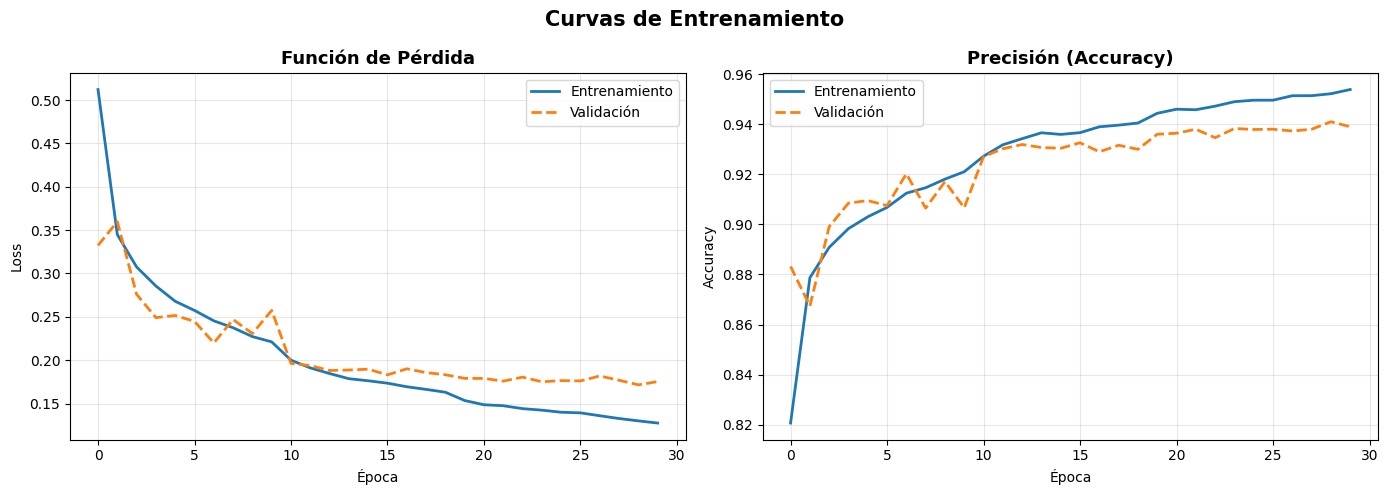

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pérdida
ax1.plot(historial.history['loss'], label='Entrenamiento', linewidth=2)
ax1.plot(historial.history['val_loss'], label='Validación', linewidth=2, linestyle='--')
ax1.set_title('Función de Pérdida', fontsize=13, fontweight='bold')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Precisión
ax2.plot(historial.history['accuracy'], label='Entrenamiento', linewidth=2)
ax2.plot(historial.history['val_accuracy'], label='Validación', linewidth=2, linestyle='--')
ax2.set_title('Precisión (Accuracy)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Curvas de Entrenamiento', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
#Accuracy final
loss, accuracy = modelo.evaluate(datos_prueba, verbose=0)
print(f"Loss en prueba:     {loss:.4f}")
print(f"Accuracy en prueba: {accuracy*100:.2f}%")

Loss en prueba:     0.1716
Accuracy en prueba: 94.10%


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


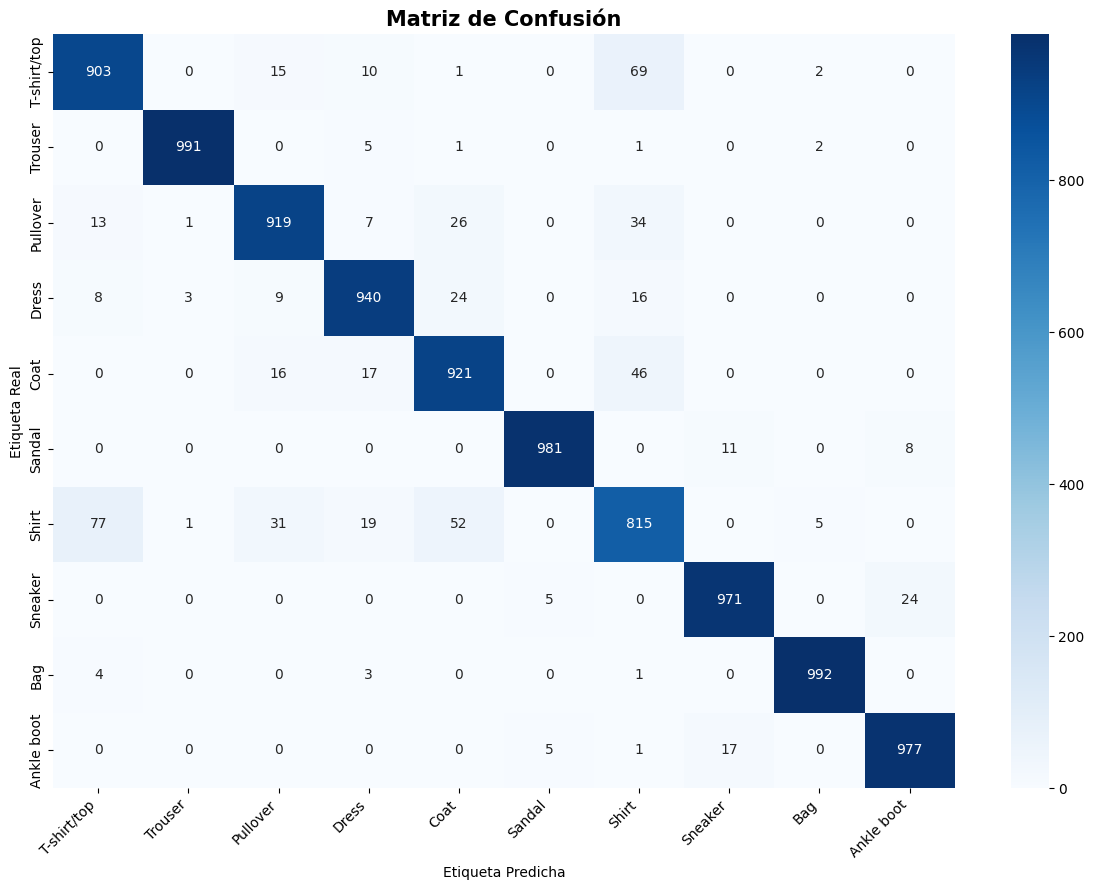

In [14]:
#Mostaré una matriz de confusión para ver como podría mejorar el dataset
# Obtener todas las predicciones y etiquetas reales
y_pred_probs = modelo.predict(datos_prueba, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

y_real = np.concatenate([y.numpy() for _, y in datos_prueba])

# Matriz de confusión
cm = confusion_matrix(y_real, y_pred)

plt.figure(figsize=(12, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=nombre_clases,
    yticklabels=nombre_clases
)
plt.title('Matriz de Confusión', fontsize=15, fontweight='bold')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()